In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import os
import logging

import matplotlib.pyplot as plt  # type: ignore
import numpy as np

import healpy as hp
from tqdm.auto import tqdm

from mlpng import Core, get_itotcov_ell
from mlpng.utils import (
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_predictions,
    plot_histogram,
    plot_elsner_comp,
    pol_str,
)
from mlpng.generator import generate_alm, generate_alm_ng, patch_and_lens
from mlpng.utils.utils import print_errors, trim_alms

logger = setup_logging(__name__, level=logging.DEBUG)

mpi_comm = None

## Elsner test

This downloads the elsner sims and prints them out as a test comparison for the linear and non-linear alms.

To download uncomment the first cell, the second cell will just plot the sims. You only need the first sim if it is taking a long time.

In [ ]:
# import requests

# for num in range(1, 1001):
#     URL1 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_l_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )
#     URL2 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_nl_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )

#     file1 = "data/elsner/alm_l_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file1):
#         with requests.Session() as s, open(file1, "wb") as f:
#             f.write(s.get(URL1).content)

#     file2 = "data/elsner/alm_nl_" + str(num).zfill(4) + "_v3.fits"
#     if not os.path.exists(file2):
#         with requests.Session() as s, open(file2, "wb") as f:
#             f.write(s.get(URL2).content)

#     print(f"Finished {num}")

In [ ]:
core = Core(
    [
        "settings/elsner.json",
        "--nsims",
        "1",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        "--pols",
        "T",
    ]
)

In [ ]:
core.init_estimator(verbose=True)

In [ ]:
idx = str(1).zfill(4)
base1 = f"data/elsner/alm_l_{idx}_v3.fits"
base2 = f"data/elsner/alm_nl_{idx}_v3.fits"

# these load the TT, EE, TE alms
alm_elsner_l = np.array(hp.read_alm(base1, hdu=(1, 2, 3)))
alm_elsner_nl = np.array(hp.read_alm(base2, hdu=(1, 2, 3)))

t_scale = core.cosmo.camb_params.TCMB * 1e6
alm_elsner_l *= t_scale
alm_elsner_nl *= t_scale

In [ ]:
icov = np.where(core.s_ell != 0, 1 / core.s_ell, 0)
icov = icov[core.pol_idxs()]


def icov_func(alm):
    ret = np.zeros_like(alm)
    for pol in range(np.shape(alm)[0]):
        # we drop
        ret[pol] = hp.almxfl(alm[pol], icov[pol])
    return ret

In [ ]:
theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus

if core.force_ksw:
    if os.path.exists(core.mc_file):
        logger.info("Loading KSW state from %s", core.mc_file)
        core.estimator.start_from_read_state(core.mc_file)
    else:
        alm_steps = generate_alm(core, 100)
        logger.debug("Done")

        def step_loader(idx):
            """for stepping the KSW estimator, we just generate new unique sims"""
            logger.debug("Sending alm step %s", idx)
            return alm_steps[idx, : core.npols]

        logger.info("Running KSW step, num steps: %s", 100)
        core.estimator.step_batch(step_loader, range(100), theta_batch=theta_batch)

        # save the mc state if we are using the mc file
        if True:
            logger.info("Saving KSW state to %s", core.mc_file)
            core.estimator.write_state(core.mc_file)

else:
    with np.errstate(divide="ignore", invalid="ignore"):
        icov = np.where(core.s_ell != 0, 1 / core.s_ell, 0)
        icov = icov[core.pol_idxs()]

    fisher = core.estimator.compute_fisher_isotropic(icov)
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

In [ ]:
pbar = tqdm(total=core.nsims, desc="Computing estimates")

idxs = range(1, core.nsims + 1)
fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims,))


def icov_func(alm):
    ret = np.zeros_like(alm)
    for pol in range(core.npols):
        ret[pol] = hp.almxfl(alm[pol], icov[pol])
    return ret


def alm_loader(i):
    idx = str(i).zfill(4)
    base1 = f"data/elsner/alm_l_{idx}_v3.fits"
    base2 = f"data/elsner/alm_nl_{idx}_v3.fits"

    # these load the TT, EE, TE alms
    l = np.array(hp.read_alm(base1, (1, 2)))[core.pol_idxs()]
    nl = np.array(hp.read_alm(base2, (1, 2)))[core.pol_idxs()]

    alms = (l + fnls[i - 1] * nl) * t_scale

    # need sto trim the values if we are using a lower lmax, throw error if asking for higher lmax
    lmax = hp.Alm.getlmax(alms.shape[-1])
    if lmax < core.lmax:
        # this could be done earlyer but this is just test code so not super important to optimize
        raise ValueError(
            "alm has lmax %s < %s which cannot be resolved", lmax, core.lmax
        )
    if lmax > core.lmax:
        # logger.debug("Trimming alm from lmax %s to %s", lmax, core.lmax)
        alms = trim_alms(alms, core.lmax)
    pbar.update(1)
    return alms


# icov_alms = [icov_func(alm_loader(i)) for i in idxs]
estimates, _, _, _ = core.estimator.compute_estimate_batch(
    lambda i: icov_func(alm_loader(i)),
    idxs,
    theta_batch=theta_batch,
    fisher=fisher,
    lin_term=0,
)
pbar.close()

In [ ]:
print_errors(fnls, estimates, fisher)
plot_predictions(fnls, estimates, fisher=fisher, show=True)
plot_histogram(fnls, estimates, show=True)

## Setup

In [120]:
core = Core(
    [
        "settings/n128.json",
        "--nsims",
        "50",
        "--narray",
        "1",
        "--fnl_range",
        "-100",
        "100",
        "--pols",
        "TE",
        # "--no-noise",
        # "--nside",
        # "128",
        # "--lmax",
        # "383",
    ]
)

01-Nov-24 15:07:21 - mlpng.core - INFO - Parsing CLI args: ['settings/n128.json', '--nsims', '50', '--narray', '1', '--fnl_range', '-100', '100', '--pols', 'TE']
01-Nov-24 15:07:21 - mlpng.core - INFO - Loading settings from file 'settings/n128.json'
01-Nov-24 15:07:21 - mlpng.core - DEBUG - Forcing setting 'nsims' to 50 due to CLI
01-Nov-24 15:07:21 - mlpng.core - DEBUG - Forcing setting 'narray' to 1 due to CLI
01-Nov-24 15:07:21 - mlpng.core - DEBUG - Forcing setting 'fnl_range' to [-100.0, 100.0] due to CLI
01-Nov-24 15:07:21 - mlpng.core - DEBUG - Forcing setting 'pols' to ['TE'] due to CLI
01-Nov-24 15:07:21 - mlpng.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.66, 'As': 2.1056e-09, 'ns': 0.9665, 'ombh2': 0.02242, 'omch2': 0.11933, 'tau': 0.0561, 'pivot_scalar': 0.05} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05})
01-Nov-24 15:07:21 - mlpng.core - DEBUG - Overriding cosmo param 'As' from 2.13e-09 to 2.1056e-09
01-Nov-24 15:07:21 - mlpng.cor

In [121]:
core.init_estimator(verbose=False)

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [123]:
alm_l = generate_alm(core)
alm_ng = generate_alm_ng(core, alm_l.copy())

(2, 384)


TypeError: The sequence of arrays must have either 4 elements or n(n+1)/2 elements (some may be None)

In [ ]:
fnls = core.rng.uniform(core.fnl_min, core.fnl_max, (core.nsims,))
alms = alm_l + fnls[:, None, None] * alm_ng

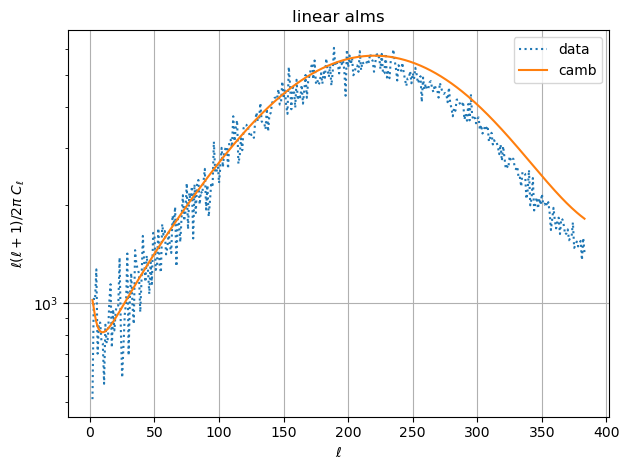

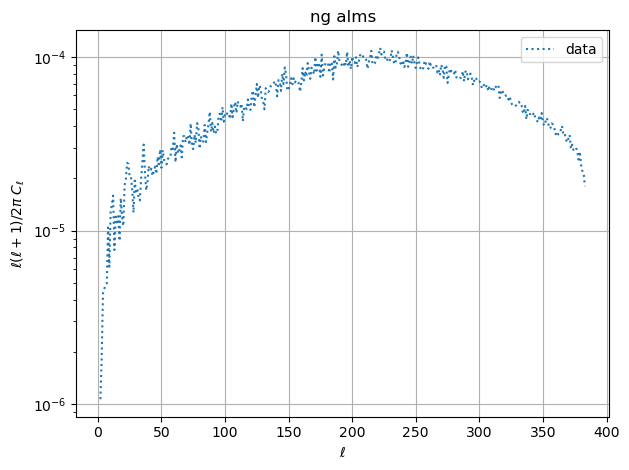

In [ ]:
plot_cl_alm(
    core,
    alm_l[0],
    title="linear alms",
    # labels=plt_labels,
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=False,
    show=True,
)

plot_cl_alm(core, alm_ng[0], title="ng alms", show=True)

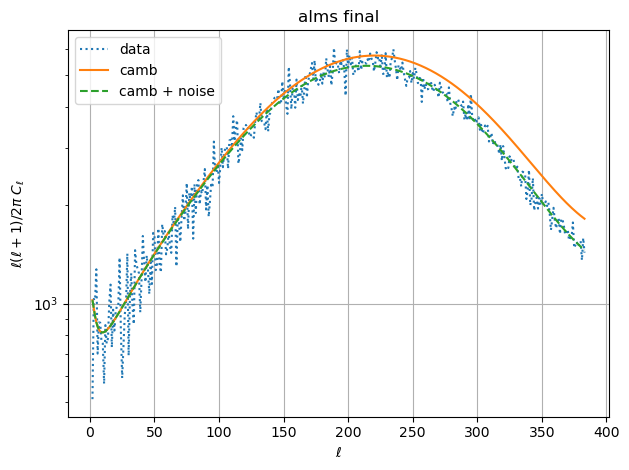

In [ ]:
plot_cl_alm(
    core,
    alms[0],
    title="alms final",
    plot_camb=True,
    plot_noise=False,
    plot_full_camb=True,
    show=True,
)

## Lensing and Patching

In [ ]:
patches, alm_lensed = patch_and_lens(core, alms)

01-Nov-24 14:59:29 - generator - DEBUG - Generating patch geometry
01-Nov-24 14:59:29 - generator - DEBUG - Getting patches


Patching:   0%|          | 0/50 [00:00<?, ?it/s]

01-Nov-24 14:59:45 - generator - DEBUG - Memory usage: RSS=2235.70 MB, VMS=6861.23 MB


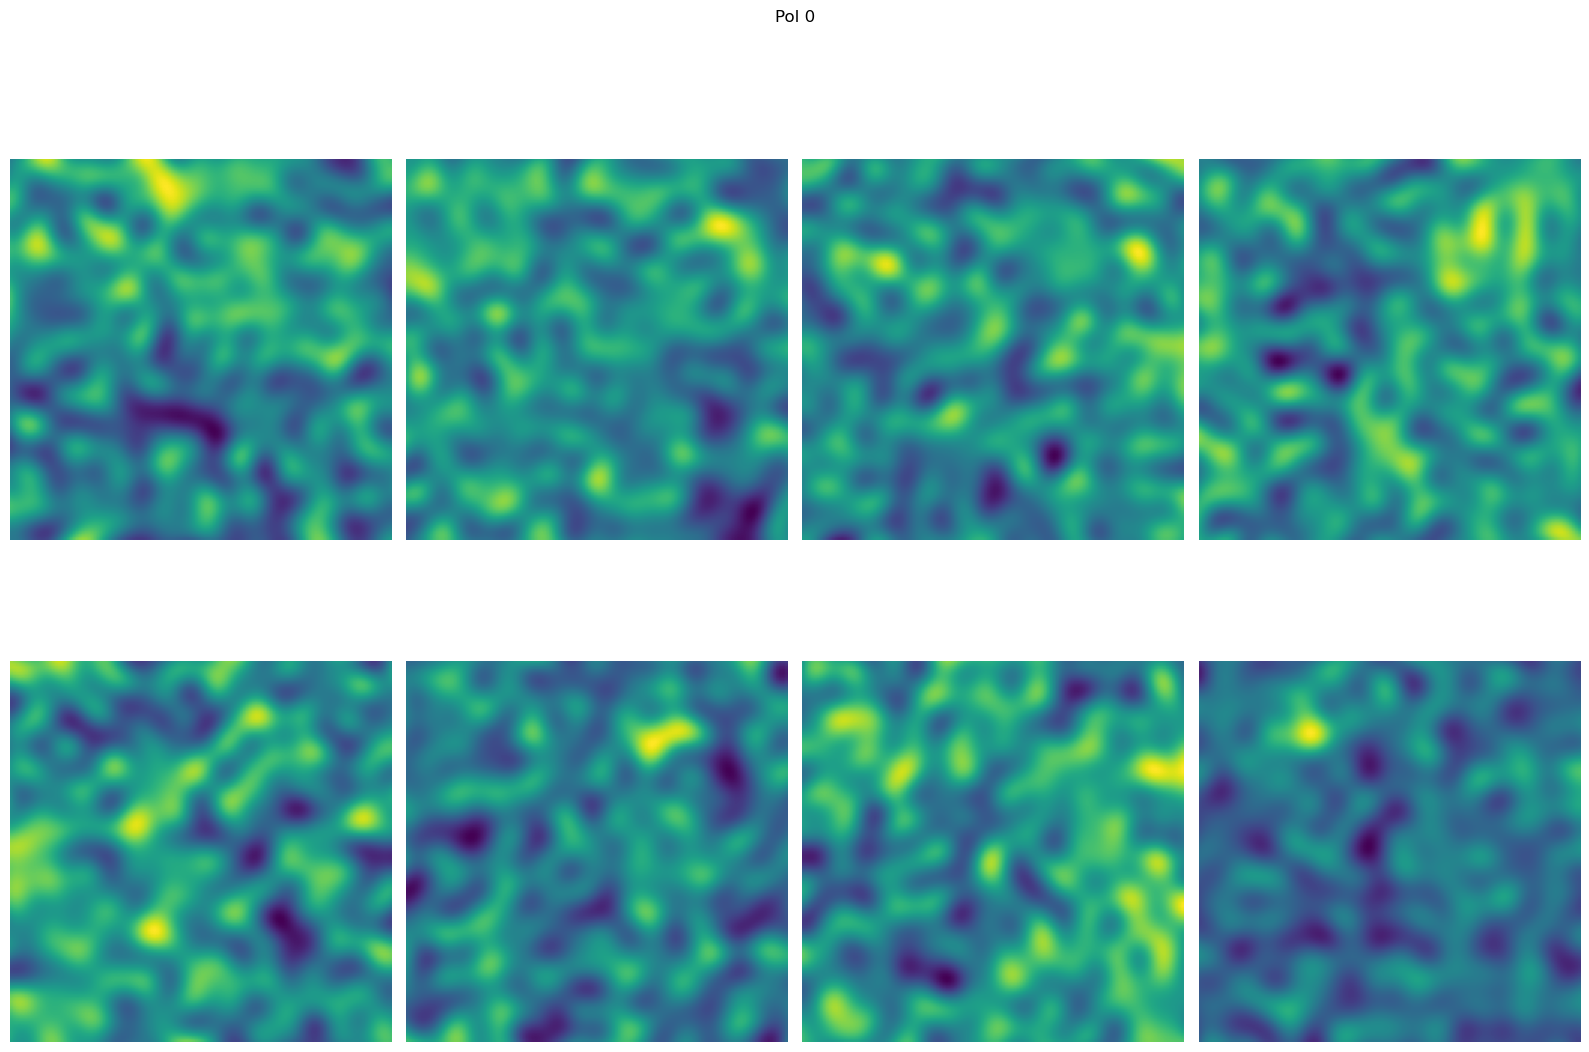

In [ ]:
for pol in range(core.npols):
    plot_patches(patches[0, :, pol], title=f"Pol {pol}", show=True)

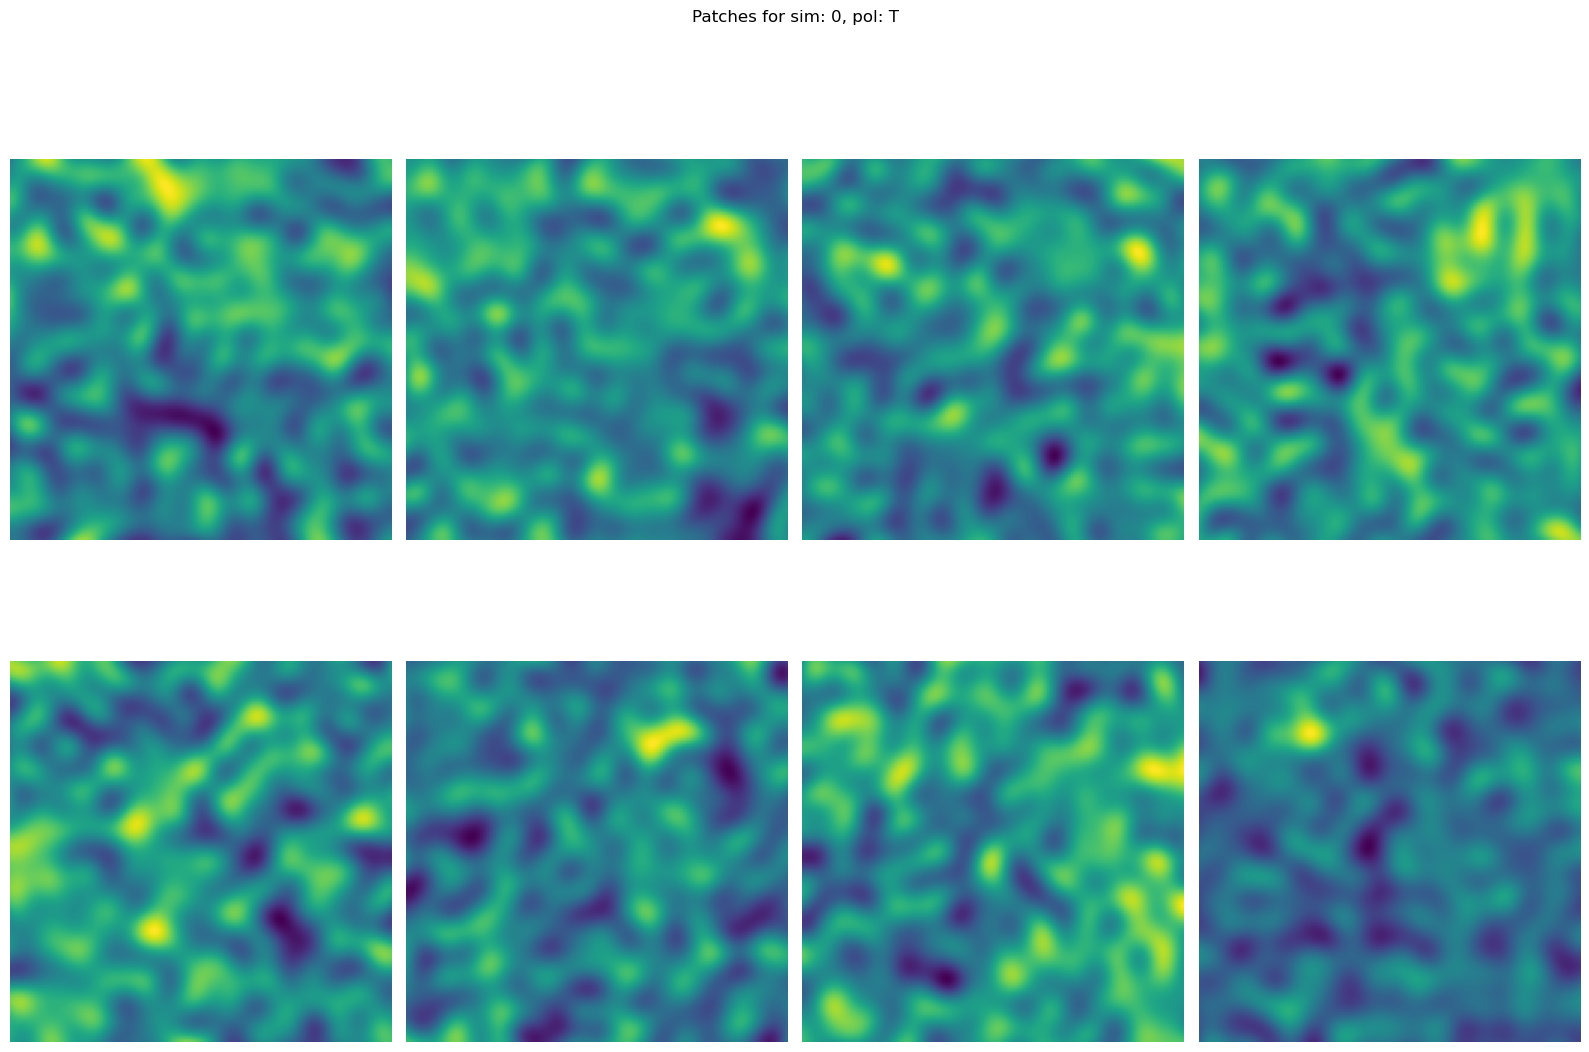

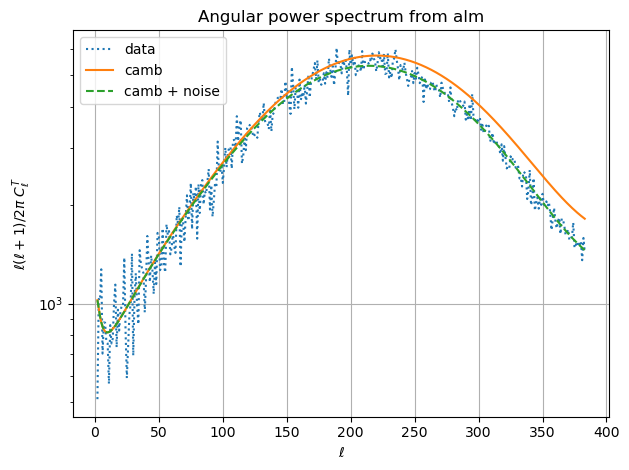

In [ ]:
sim = 0
for i, pol in enumerate(core.pol_idxs()):
    pstr = pol_str(pol)
    plot_patches(
        patches[sim, :, i], title=f"Patches for sim: {sim}, pol: {pstr}", show=True
    )

    ylabel = r"$\ell(\ell+1)/2\pi\;C_{\ell}" + f"^{pstr}$"
    plot_cl_alm(
        core,
        alms[sim, i],
        # save_file=filebase,
        ylabel=ylabel,
        plot_camb=True,
        plot_noise=False,
        plot_full_camb=True,
        show=True,
        lmin=2,
    )

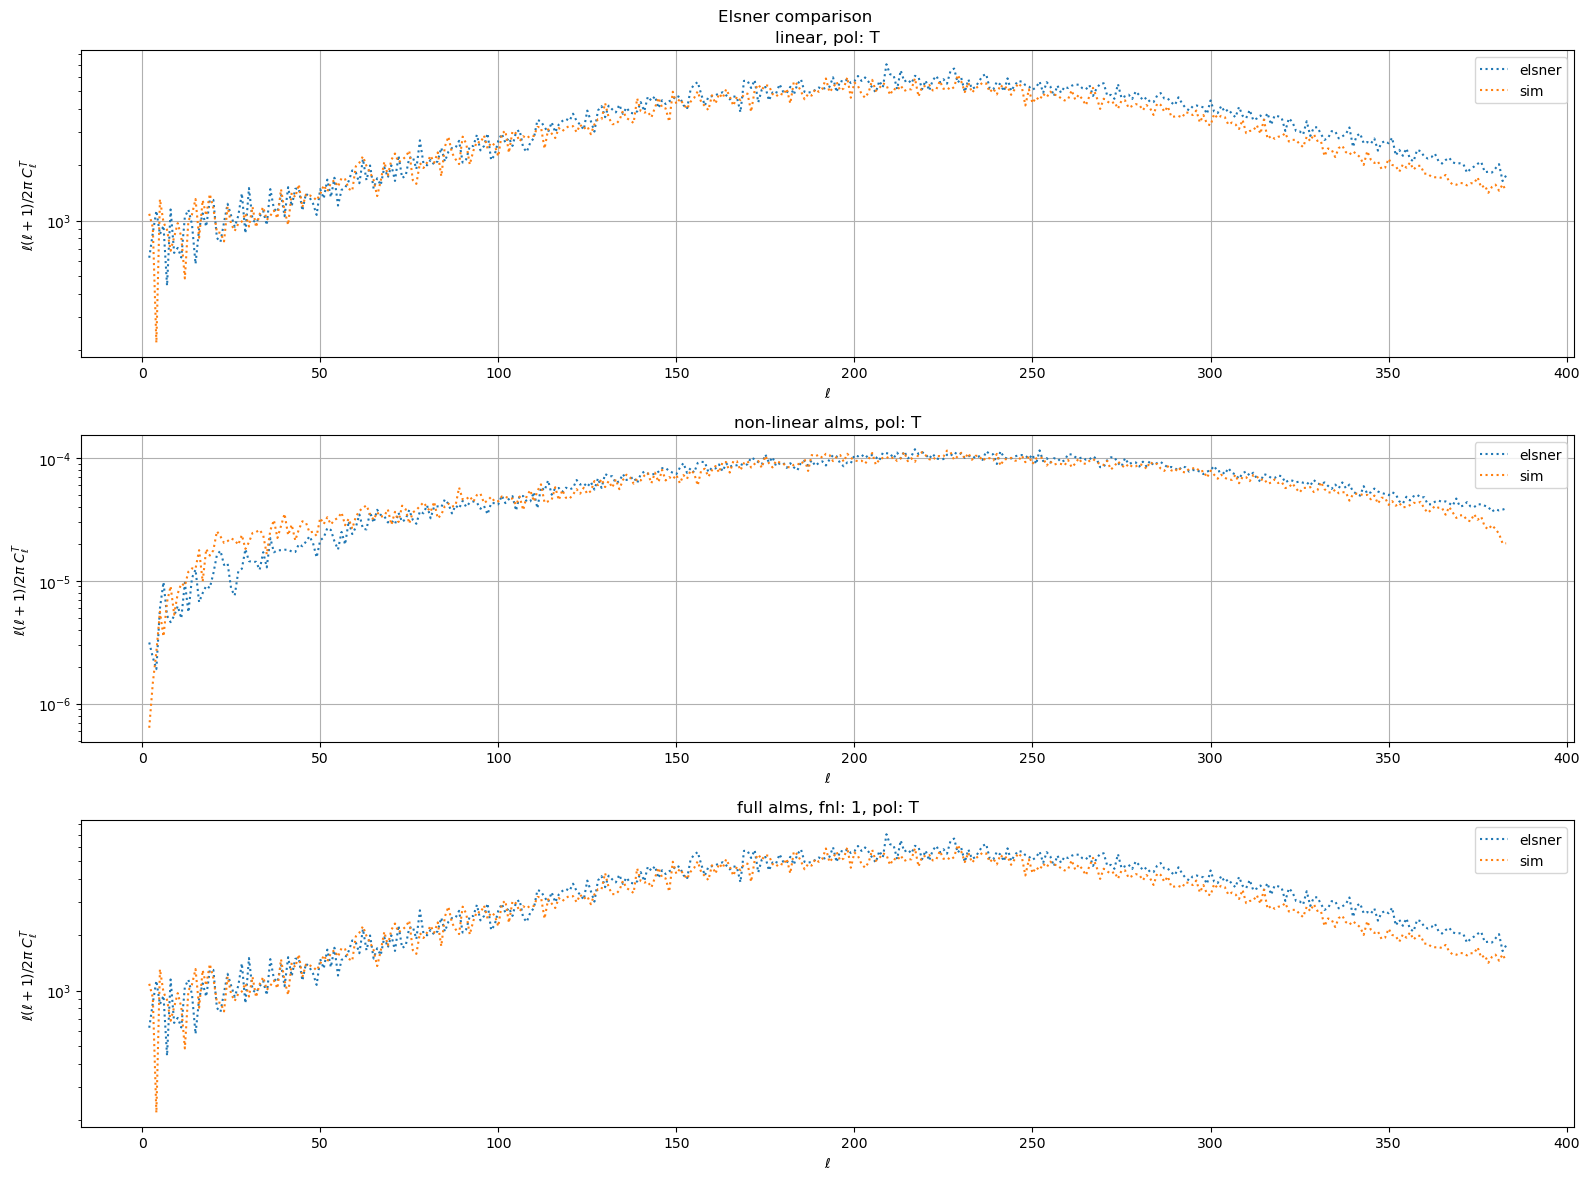

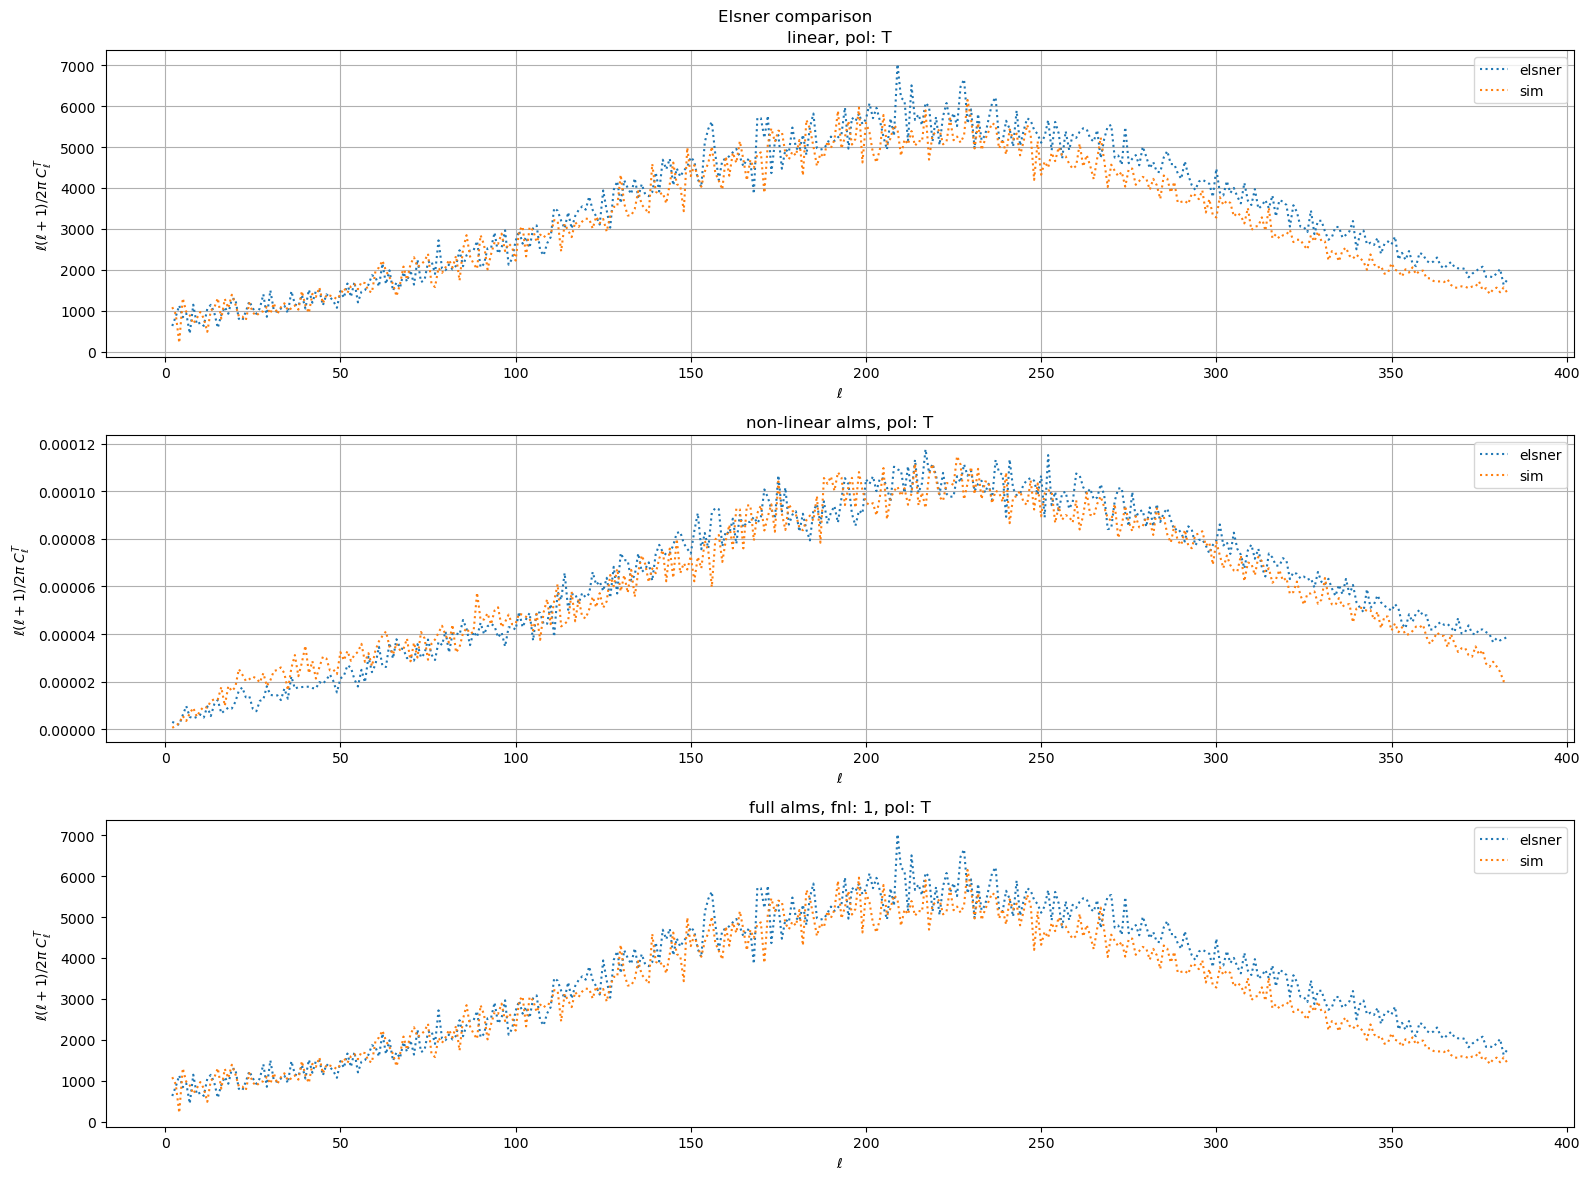

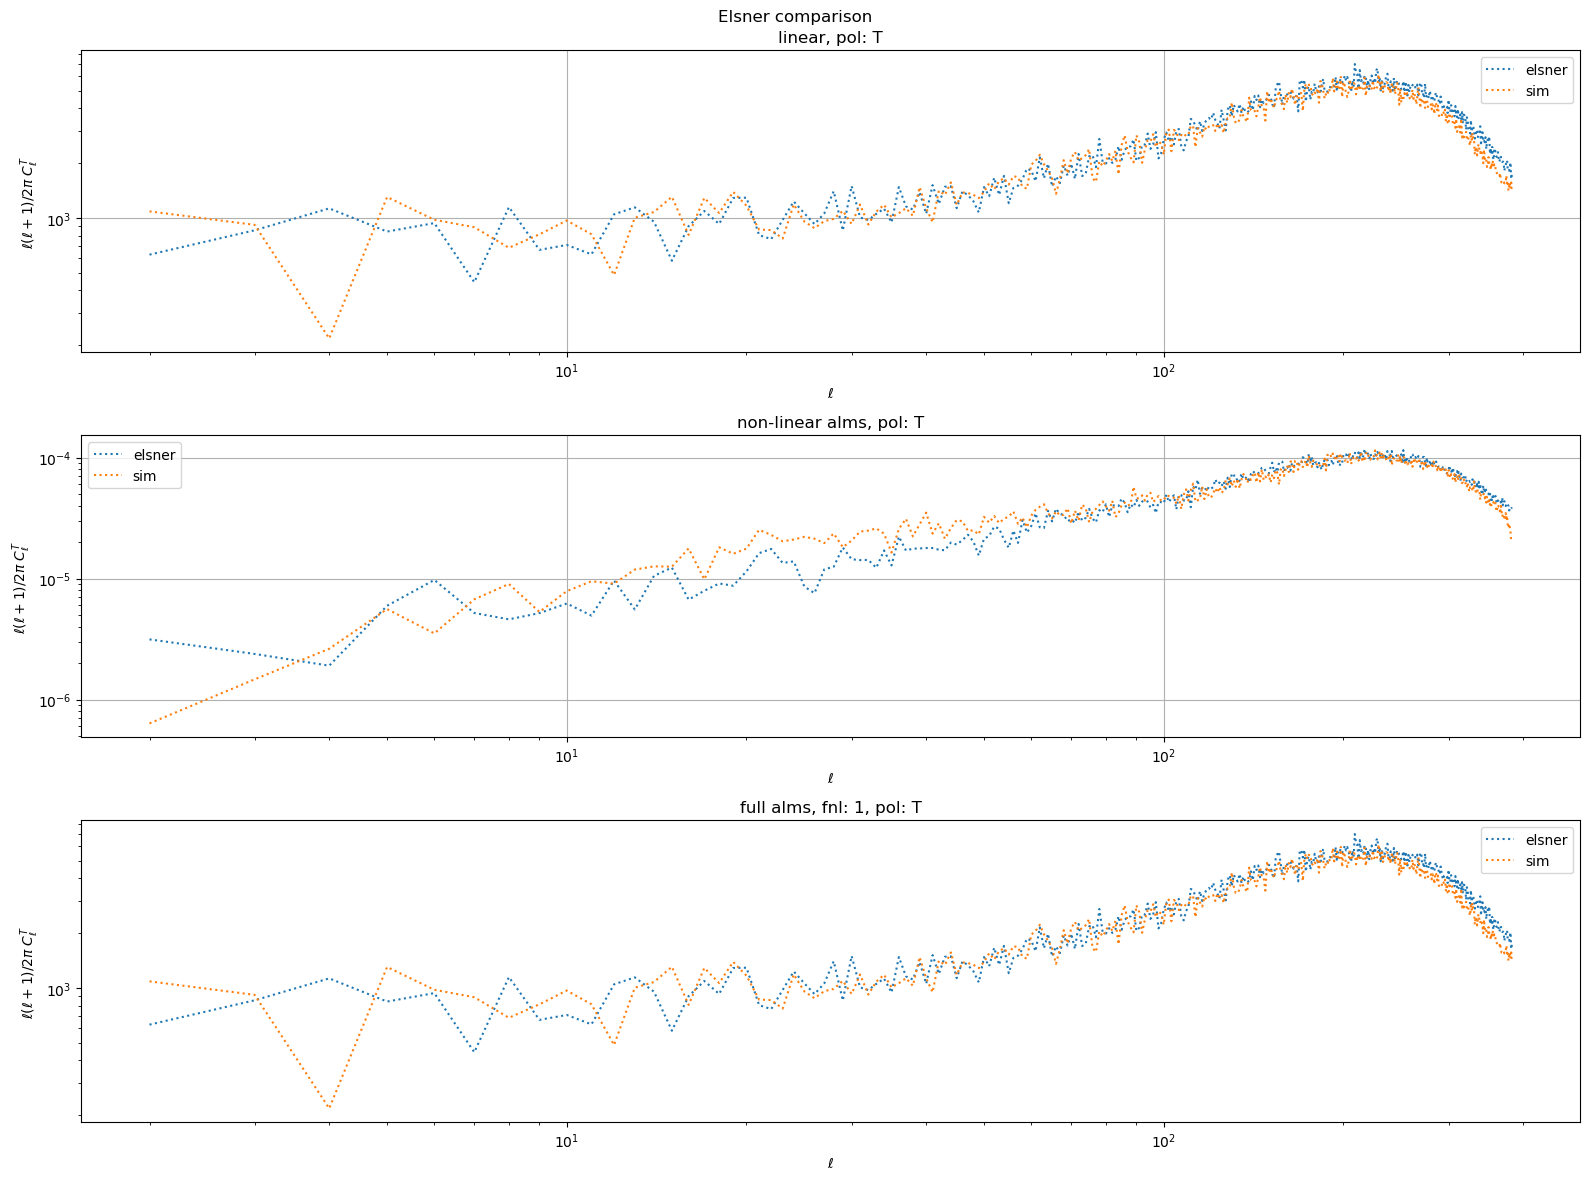

In [ ]:
sim = core.rng.integers(core.nsims)
eidx = core.rng.integers(1, 1001)
plot_elsner_comp(
    core,
    alm_l[sim],
    alm_ng[sim],
    index=eidx,
    show=True,
    elsner_pols=core.pol_idxs(),
)
plot_elsner_comp(
    core,
    alm_l[sim],
    alm_ng[sim],
    index=eidx,
    show=True,
    plot_func=plt.plot,
    elsner_pols=core.pol_idxs(),
)
plot_elsner_comp(
    core,
    alm_l[sim],
    alm_ng[sim],
    index=eidx,
    show=True,
    elsner_pols=core.pol_idxs(),
    plot_func=plt.loglog,
)

01-Nov-24 14:59:58 - mlpng.utils.plots - DEBUG - Averaging 10 elsner sims, this will take a while


Averaging elsner sims:   0%|          | 0/10 [00:00<?, ?it/s]

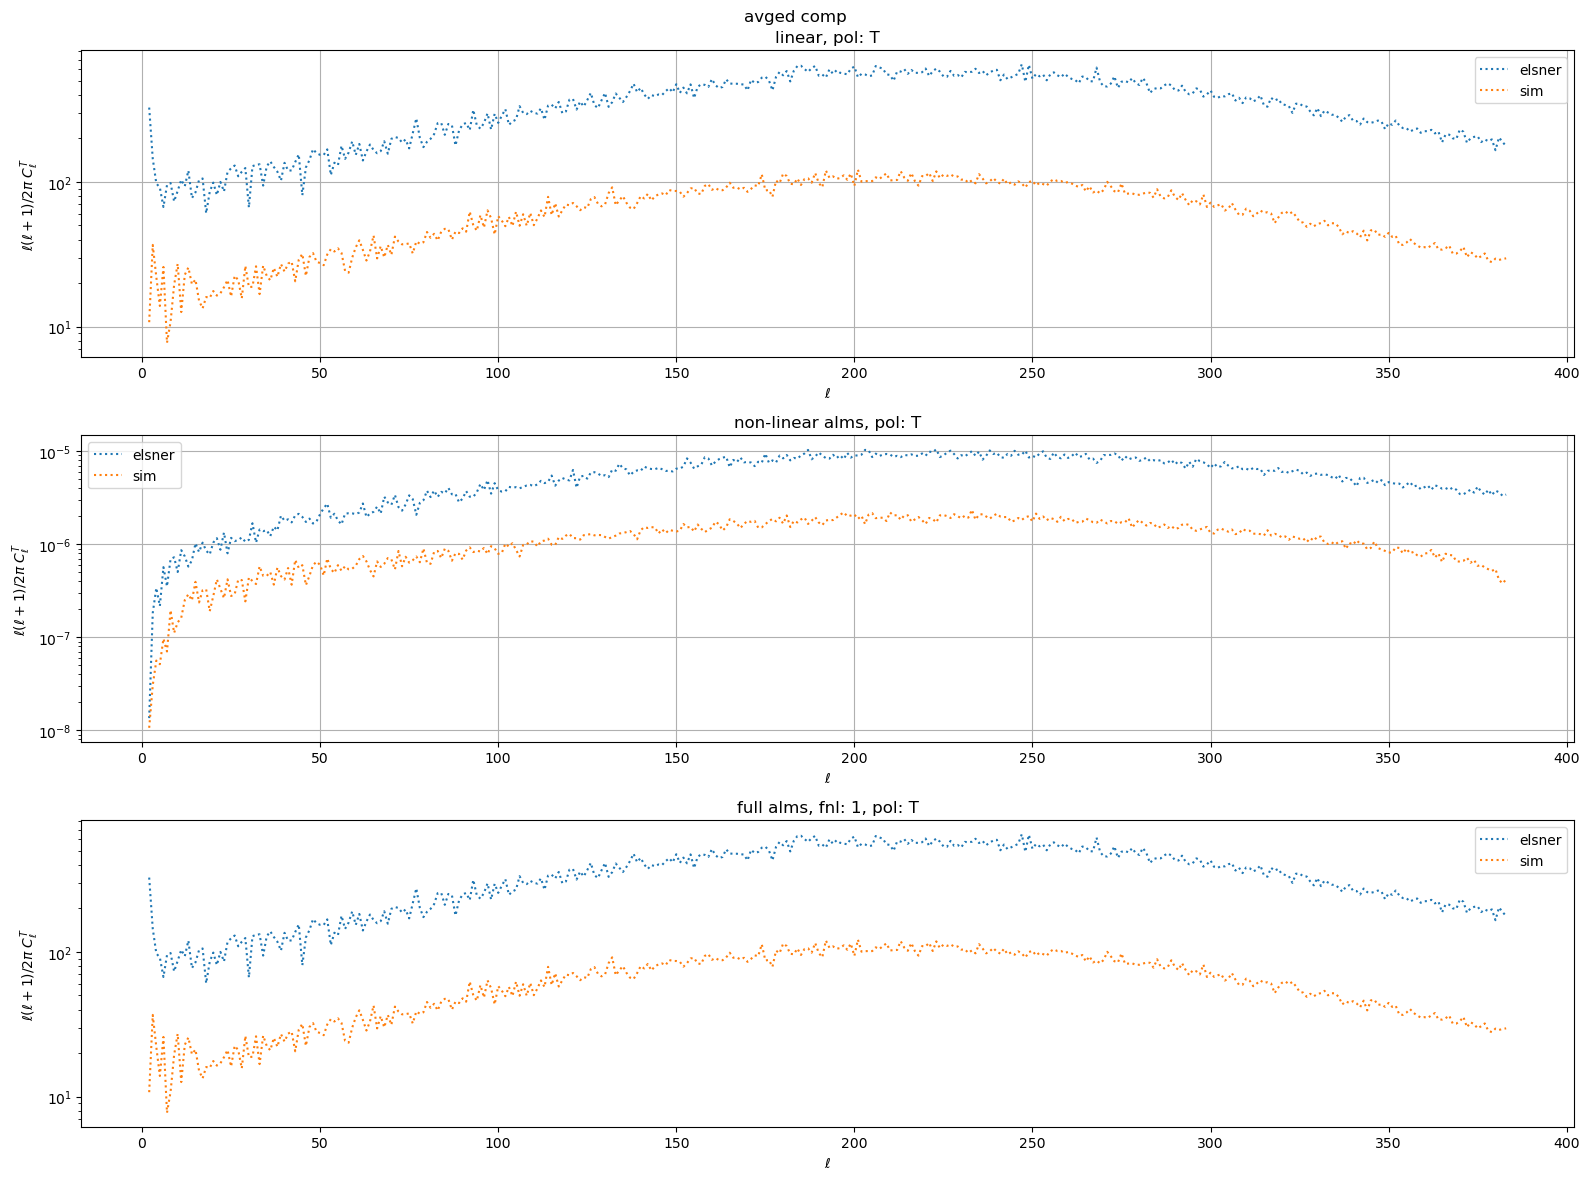

In [ ]:
alm_l_avg = np.mean(alm_l, axis=0)
alm_ng_avg = np.mean(alm_ng, axis=0)

plot_elsner_comp(
    core,
    alm_l_avg,
    alm_ng_avg,
    average=10,
    title="avged comp",
    show=True,
    plot_func=plt.semilogy,
    elsner_pols=core.pol_idxs(),
)

## Estimator

In [ ]:
theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus


# get the icov which is used in two spots below for the estimator
cov = core.c_ell  # + core.nb_ell
f_ic = np.zeros_like(cov)
f_ic[..., core.lmin :] = 1 / cov[..., core.lmin :]

if core.force_ksw:
    if os.path.exists(core.mc_file):
        logger.info("Loading KSW state from %s", core.mc_file)
        core.estimator.start_from_read_state(core.mc_file)
    else:
        alm_steps = generate_alm(core, 100)
        logger.debug("Done")

        def step_loader(idx):
            """for stepping the KSW estimator, we just generate new unique sims"""
            logger.debug("Sending alm step %s", idx)
            return alm_steps[idx, : core.npols]

        logger.info("Running KSW step, num steps: %s", 100)
        core.estimator.step_batch(step_loader, range(100), theta_batch=theta_batch)

        # save the mc state if we are using the mc file
        if True:
            logger.info("Saving KSW state to %s", core.mc_file)
            core.estimator.write_state(core.mc_file)

    fisher = core.estimator.compute_fisher()
else:
    inoise = np.full(core.n_ell.shape, 1e-16)
    inoise[..., core.lmin :] = 1 / core.n_ell[..., core.lmin :]
    # f_ic = get_itotcov_ell(f_ic, inoise, core.b_ell)
    f_ic = get_itotcov_ell(f_ic, inoise, core.b_ell)
    # f_ic[f_ic == 0] = 1e16

    logger.debug("Computing Fisher")
    fisher = core.estimator.compute_fisher_isotropic(f_ic, comm=mpi_comm)
print(f"Fisher: {fisher}, standard deviation: {1 / np.sqrt(fisher)}")

01-Nov-24 15:00:03 - __main__ - DEBUG - Computing Fisher


Fisher: 0.002049623989014876, standard deviation: 22.088331028625742


In [ ]:
def alm_loader(i):
    if core.lensing:
        return alm_lensed[i]
    else:
        print("true fnl:", fnls[i], end=", ")
        return alms[i].copy()


def icov_func(alm, icov):
    ret = np.zeros_like(alm)
    for pol in range(np.shape(alm)[0]):
        ic = icov[pol, pol] if icov.ndim == 3 else icov[pol]
        ret[pol] = hp.almxfl(alm[pol], ic.copy())
    # ret[ret == 0] = 1e16
    return ret


idxs = range(core.nsims)

# C_ell here should be the C^TT_ell + N_ell, total signal + noise power spectrum per smith and zald
cov = core.c_ell + core.n_ell / core.b_ell**2
icov = np.zeros_like(core.s_ell)
icov[..., core.lmin :] = 1 / (cov)[..., core.lmin :]
icov[..., : core.lmin] = 0  # 1e-16

estimates, _, _, _ = core.estimator.compute_estimate_batch(
    lambda a: icov_func(alm_loader(a), icov * core.b_ell**2),
    idxs,
    theta_batch=theta_batch,
    fisher=fisher,
    lin_term=0,
)

true fnl: 34.36583396840393, fnl=43.79102775910314, t_cubic=0.08975514099867414, lin_term=0, fisher=0.002049623989014876
true fnl: 19.889122786409928, fnl=28.624111561753963, t_cubic=0.05866866572120899, lin_term=0, fisher=0.002049623989014876
true fnl: 84.42869033138908, fnl=102.98160721896058, t_cubic=0.21107357258328913, lin_term=0, fisher=0.002049623989014876
true fnl: -76.72150949303966, fnl=-69.0781086391975, t_cubic=-0.14158414858267493, lin_term=0, fisher=0.002049623989014876
true fnl: 74.28507591215933, fnl=86.21195769783085, t_cubic=0.17670209663740982, lin_term=0, fisher=0.002049623989014876
true fnl: 67.03431984553333, fnl=82.53666169010901, t_cubic=0.16916912177325255, lin_term=0, fisher=0.002049623989014876
true fnl: -63.97306105140892, fnl=-61.14506234576783, t_cubic=-0.12532438659369596, lin_term=0, fisher=0.002049623989014876
true fnl: -72.11657495616464, fnl=-83.54144299070613, t_cubic=-0.17122854563066997, lin_term=0, fisher=0.002049623989014876
true fnl: 17.15578449

01-Nov-24 15:02:44 - mlpng.utils.utils - INFO - Standard deviation: 22.088331028625742, SEM: 3.123761731086898
01-Nov-24 15:02:44 - mlpng.utils.utils - INFO - 68.0% (57.99999999999999, 74.0) are within 1 standard deviations
01-Nov-24 15:02:44 - mlpng.utils.utils - INFO - 96.0% (94.0, 98.0) are within 2 standard deviations
01-Nov-24 15:02:44 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 3 standard deviations
01-Nov-24 15:02:44 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 4 standard deviations
01-Nov-24 15:02:44 - mlpng.utils.utils - INFO - 100.0% (100.0, 100.0) are within 5 standard deviations


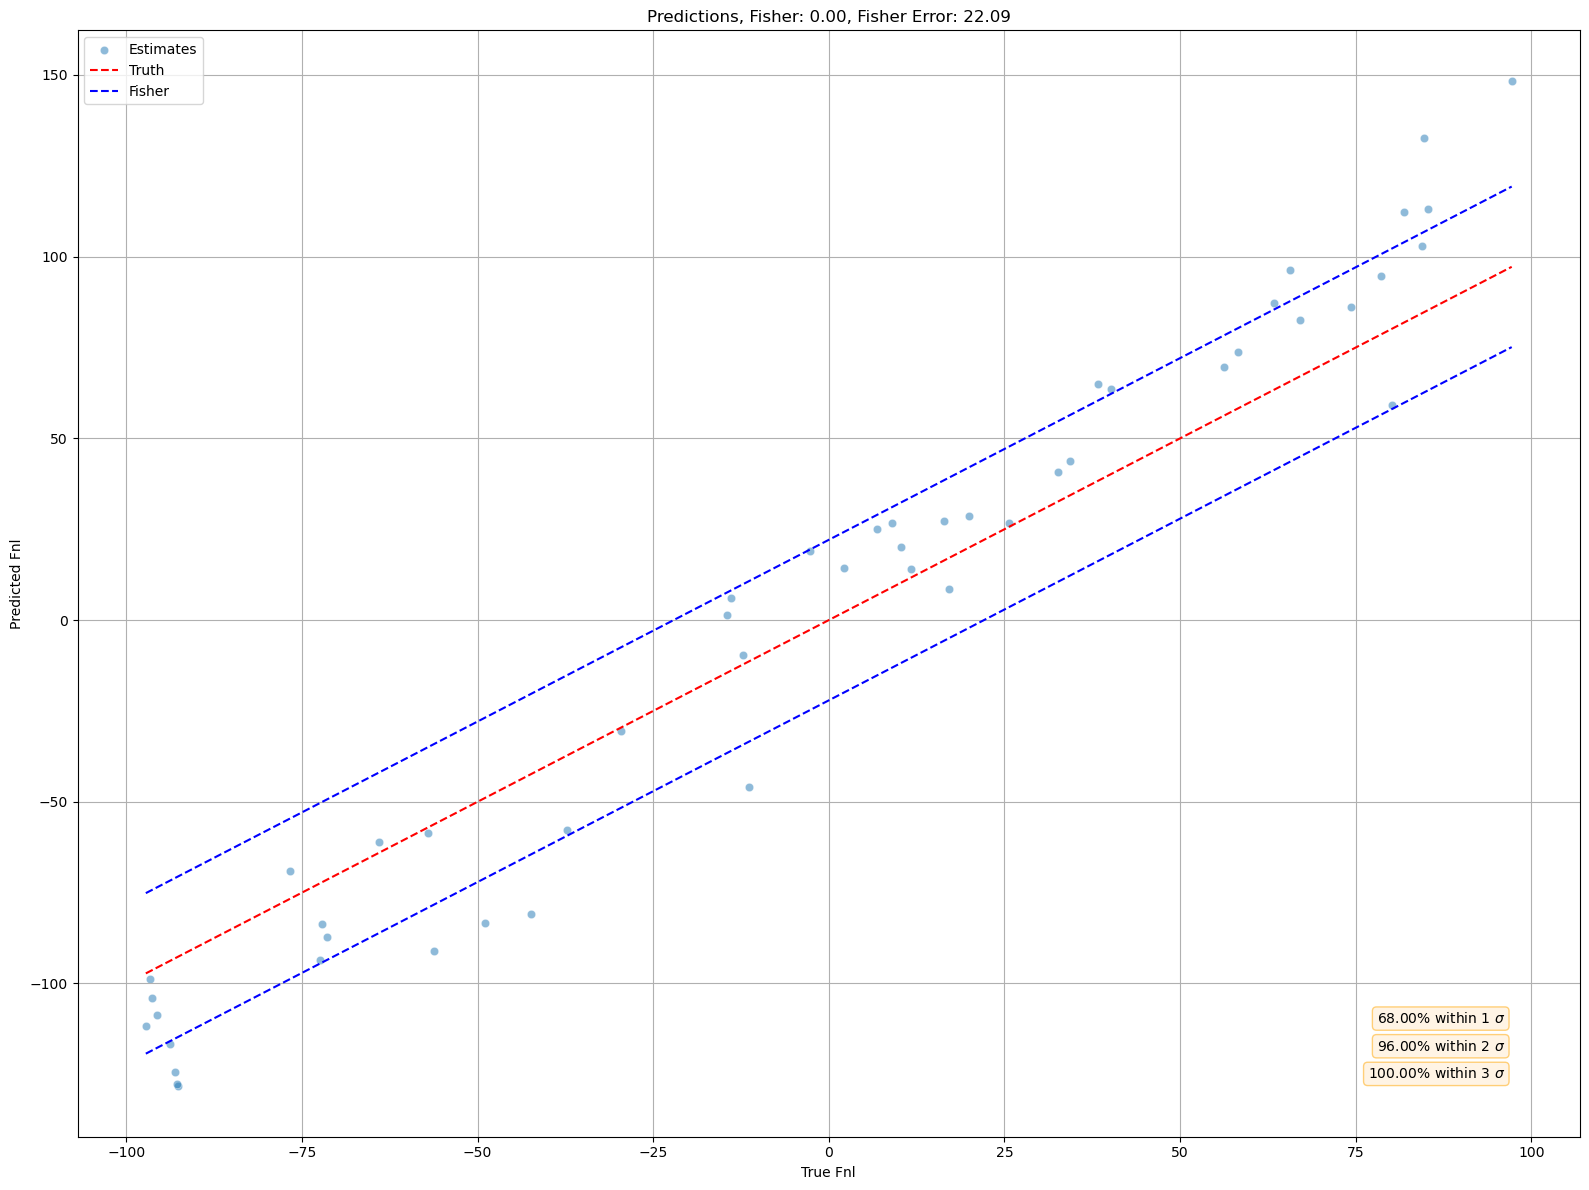

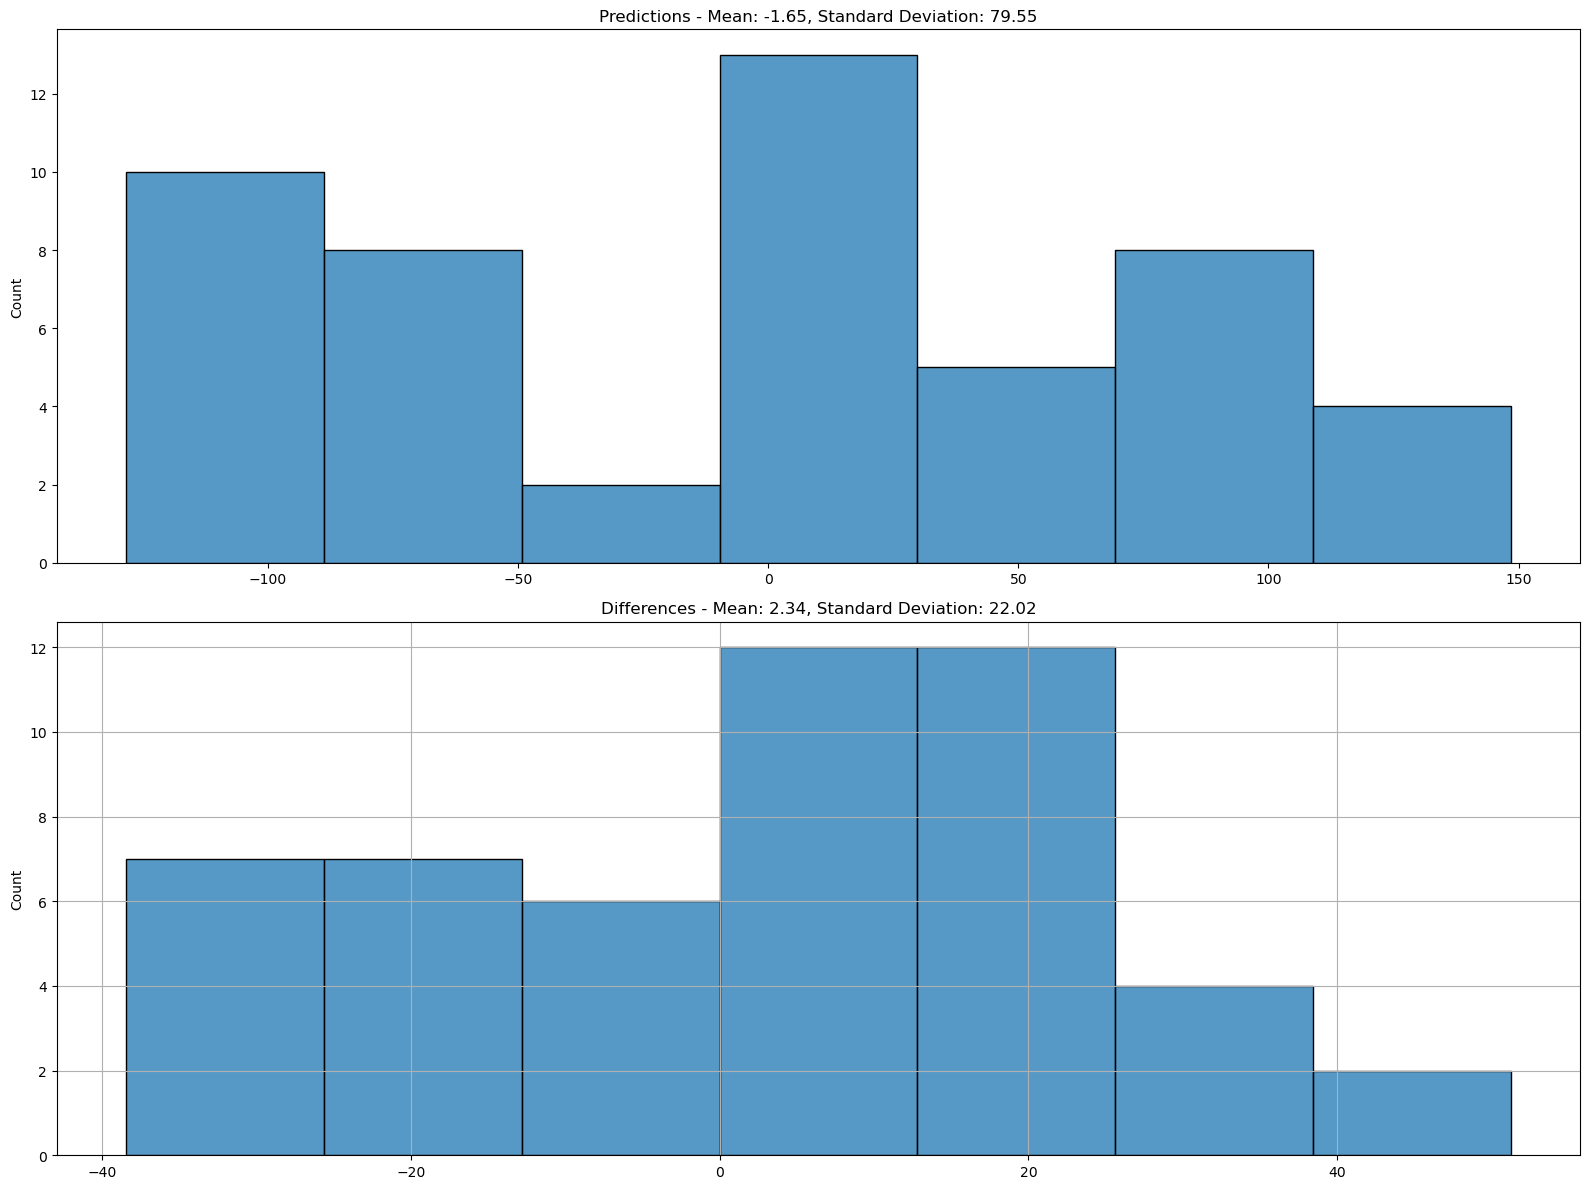

In [ ]:
print_errors(fnls, estimates, fisher)
plot_predictions(fnls, estimates, fisher=fisher, show=True)
plot_histogram(fnls, estimates, show=True)